# Description

In this notebook, we apply CEQL method to approximate the frequency response function of a beam.

Loaded conditions:
  Healthy: n_files=70, det=P-1.txt, n_freq=6400
  Damage 2.96%: n_files=70, det=P-1-1.txt, n_freq=6400
  Damage 5.92%: n_files=70, det=P-1-2.txt, n_freq=6400
  Damage 8.87%: n_files=70, det=P-1-3.txt, n_freq=6400


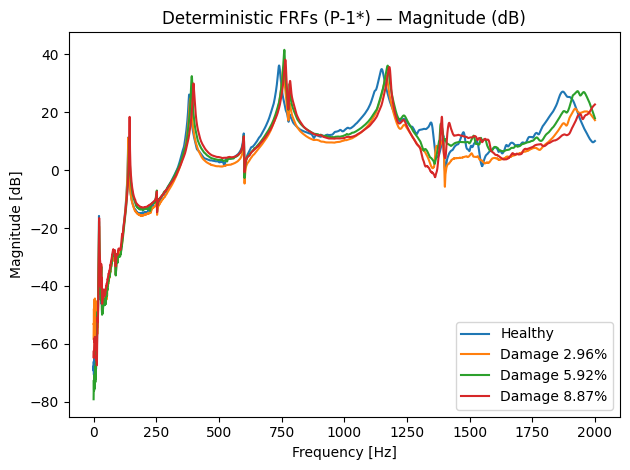

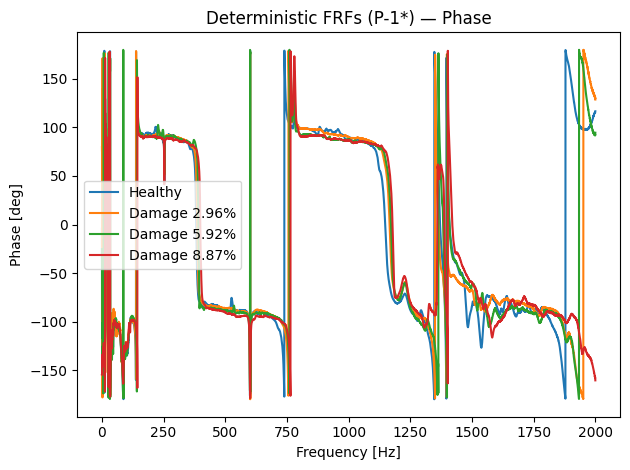

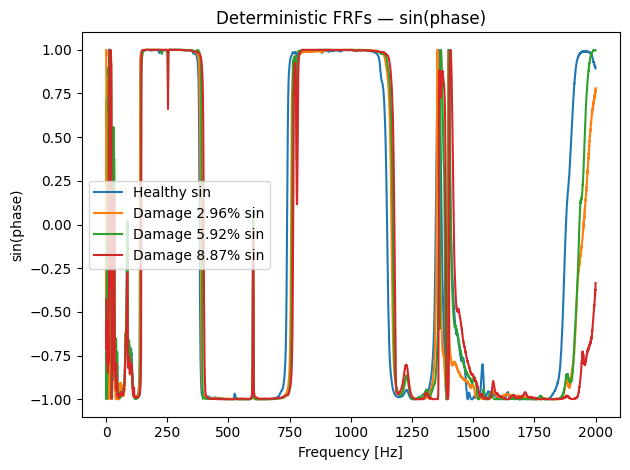

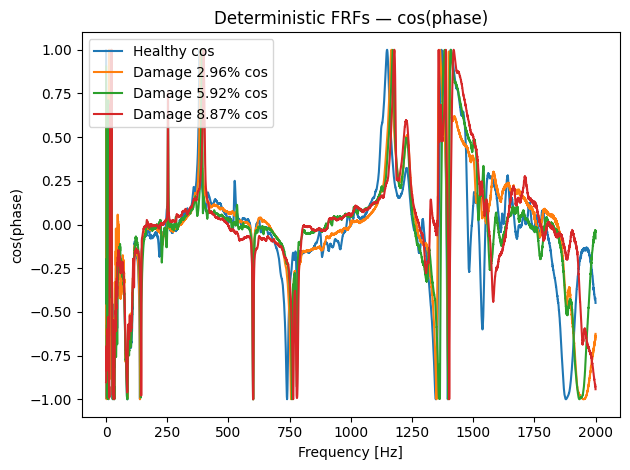

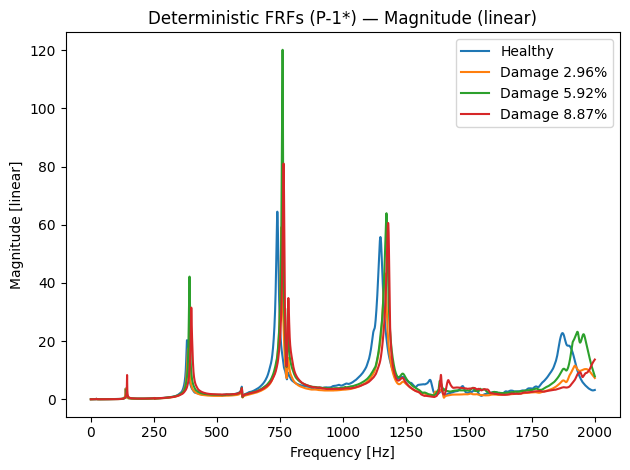

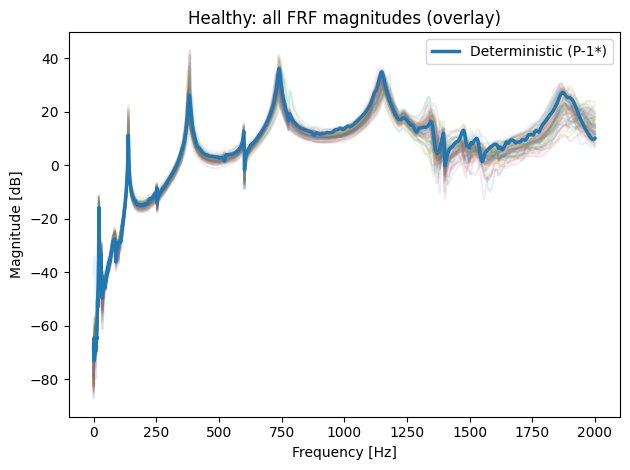

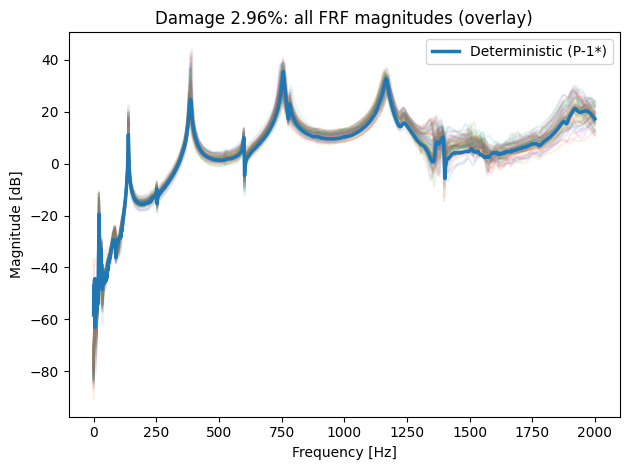

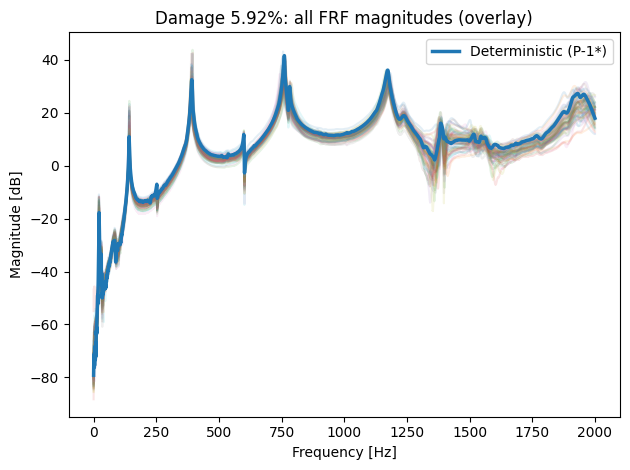

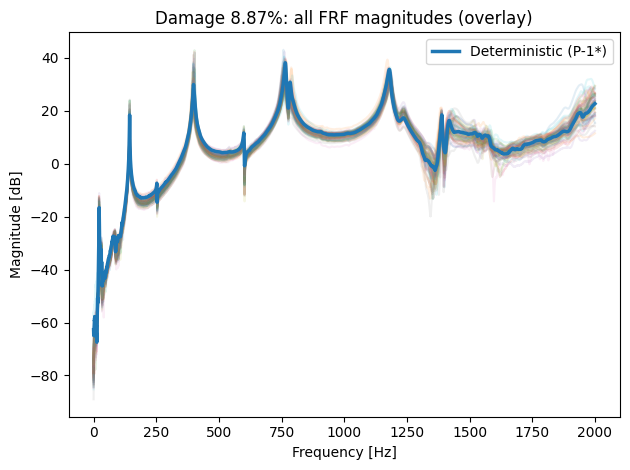

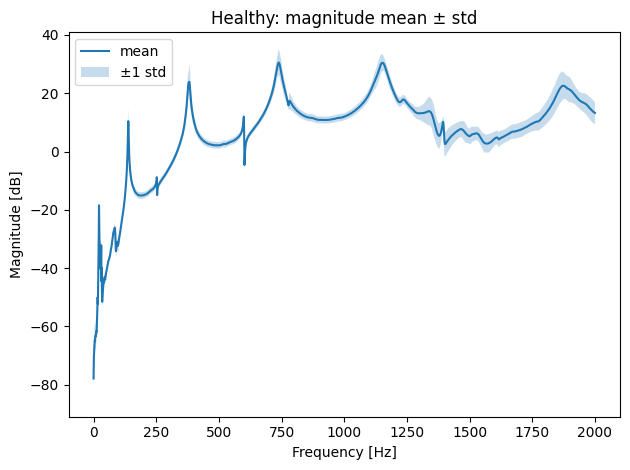

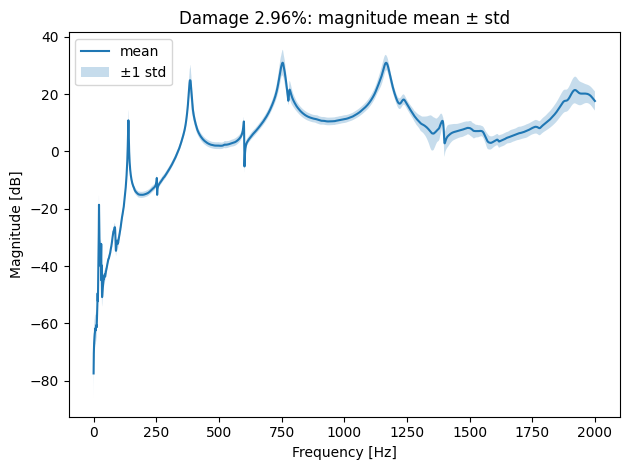

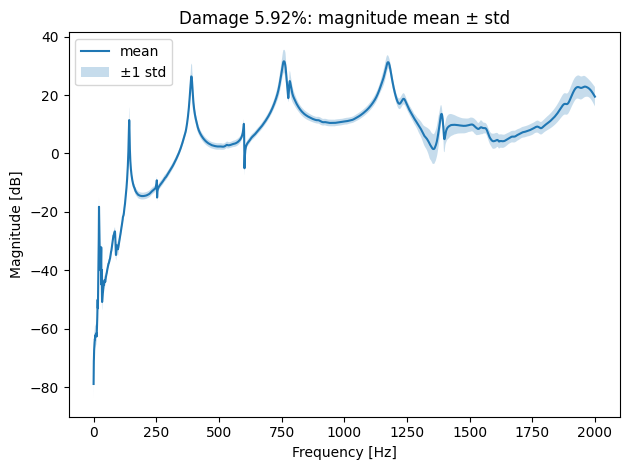

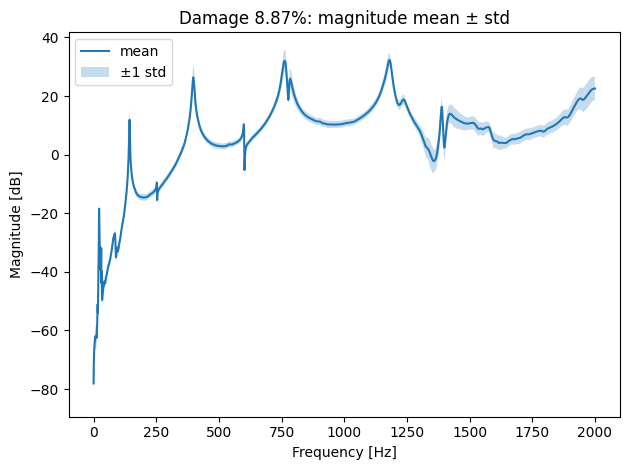

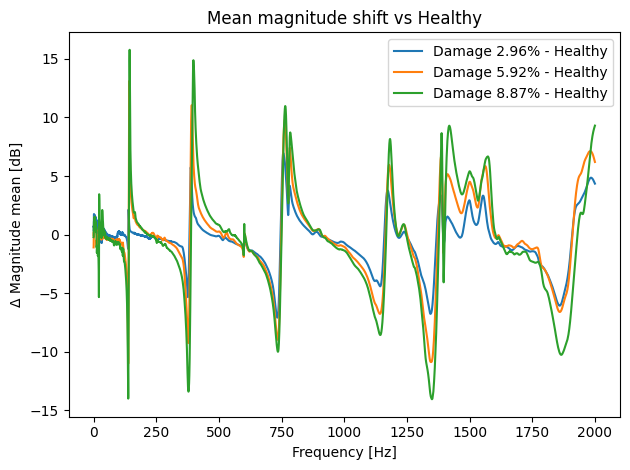

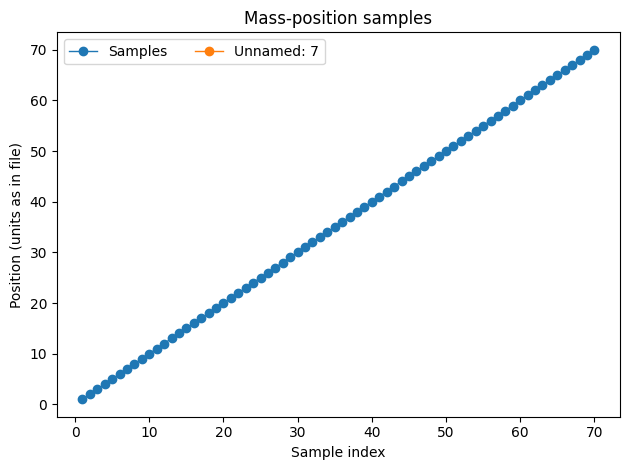

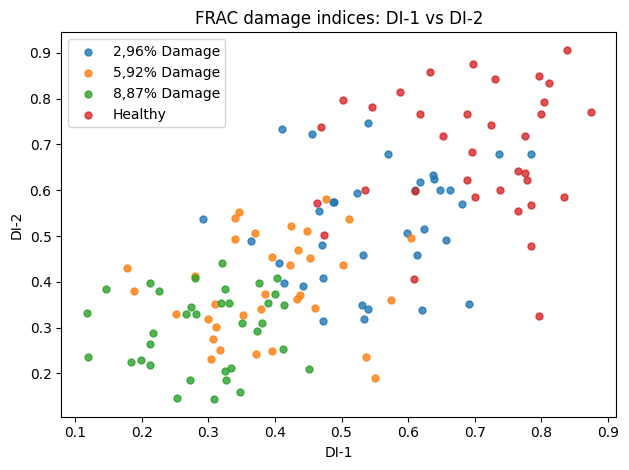

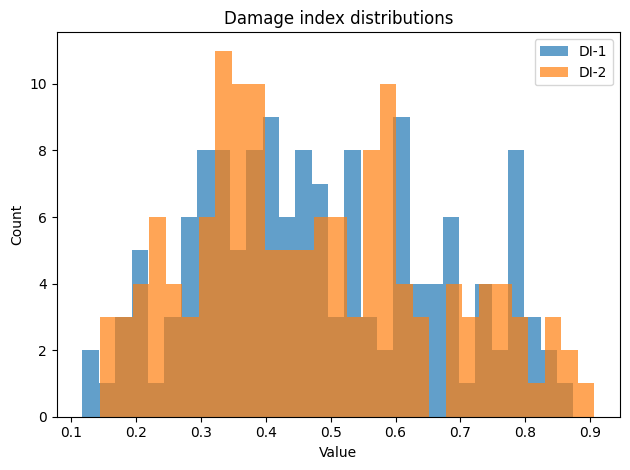

In [1]:
from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Paths (run from the folder that contains frf_data/)
# -----------------------------
try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()

DATA = ROOT / "frf_data"

FRF_FOLDERS = {
    "Healthy": DATA / "1-Beam_healthy",
    "Damage 2.96%": DATA / "2-Beam_damage_2.96",
    "Damage 5.92%": DATA / "3-Beam_damage_5.92",
    "Damage 8.87%": DATA / "4-Beam_damage_8.87",
}

MASS_POS_XLSX = DATA / "Mass position.xlsx"
DI_XLSX = DATA / "DI_FRAC_Exp-estimation.xlsx"


# -----------------------------
# dB -> linear conversion
# Assumes amplitude dB: mag_db = 20 * log10(mag_lin / ref)
# ref=1.0 means "relative linear units"
# -----------------------------
def db_to_linear(mag_db: np.ndarray, ref: float = 1.0) -> np.ndarray:
    return ref * (10.0 ** (mag_db / 20.0))

def phase_sin_cos(phase_deg: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    phase_rad = np.deg2rad(phase_deg)
    return np.sin(phase_rad), np.cos(phase_rad)

# -----------------------------
# TXT reader: robust to encoding + malformed lines
# -----------------------------
_NUM = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?")

def read_frf_txt(path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    text = path.read_bytes().decode("latin-1", errors="ignore")

    f_list: list[float] = []
    m_list: list[float] = []
    p_list: list[float] = []

    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue

        nums = _NUM.findall(line)
        if len(nums) < 3:
            continue

        f = float(nums[0])
        mag = float(nums[1])
        ph = float(nums[2])

        f_list.append(f)
        m_list.append(mag)
        p_list.append(ph)

    if not f_list:
        raise ValueError(f"No numeric rows parsed from {path}")

    f = np.asarray(f_list, dtype=float)
    mag_db = np.asarray(m_list, dtype=float)
    phase_deg = np.asarray(p_list, dtype=float)

    idx = np.argsort(f)
    f = f[idx]
    mag_db = mag_db[idx]
    phase_deg = phase_deg[idx]

    return f, mag_db, phase_deg


def list_txt_files(folder: Path) -> list[Path]:
    files = sorted(folder.glob("*.txt"))
    if not files:
        raise FileNotFoundError(f"No .txt files found in {folder}")
    return files


def deterministic_file(files: list[Path]) -> Path | None:
    # P-1, P-1-1, P-1-2, ...
    for p in files:
        if re.match(r"^P-1(\D|$)", p.stem):
            return p
    return None


def stack_curves(files: list[Path]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    f0, m0, p0 = read_frf_txt(files[0])

    M = np.empty((len(files), f0.size), dtype=float)
    P = np.empty((len(files), f0.size), dtype=float)
    M[0] = m0
    P[0] = p0

    for i, fp in enumerate(files[1:], start=1):
        f, m, ph = read_frf_txt(fp)

        # interpolate onto reference frequency grid
        M[i] = np.interp(f0, f, m)
        P[i] = np.interp(f0, f, ph)

    return f0, M, P


# -----------------------------
# Load all FRFs
# -----------------------------
frf_data: dict[str, dict] = {}
for cond, folder in FRF_FOLDERS.items():
    files = list_txt_files(folder)
    det = deterministic_file(files)
    f, M, P = stack_curves(files)
    frf_data[cond] = {
        "folder": folder,
        "files": files,
        "det_file": det,
        "f": f,
        "M": M,
        "P": P,
    }

print("Loaded conditions:")
for cond, d in frf_data.items():
    print(f"  {cond}: n_files={len(d['files'])}, det={d['det_file'].name if d['det_file'] else None}, n_freq={d['f'].size}")


# -----------------------------
# Plot 1: deterministic magnitude + phase (one per condition) [dB]
# -----------------------------
plt.figure()
for cond, d in frf_data.items():
    det = d["det_file"]
    if det is None:
        continue
    f, mag_db, _ = read_frf_txt(det)
    plt.plot(f, mag_db, label=cond)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Deterministic FRFs (P-1*) — Magnitude (dB)")
plt.legend()
plt.tight_layout()

plt.figure()
for cond, d in frf_data.items():
    det = d["det_file"]
    if det is None:
        continue
    f, _, ph = read_frf_txt(det)
    plt.plot(f, ph, label=cond)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase [deg]")
plt.title("Deterministic FRFs (P-1*) — Phase")
plt.legend()
plt.tight_layout()


# -----------------------------
# Plot: deterministic sin(phase) and cos(phase)
# -----------------------------
plt.figure()
for cond, d in frf_data.items():
    det = d["det_file"]
    if det is None:
        continue
    f, _, ph = read_frf_txt(det)
    sin_ph, _ = phase_sin_cos(ph)
    plt.plot(f, sin_ph, label=f"{cond} sin")
plt.xlabel("Frequency [Hz]")
plt.ylabel("sin(phase)")
plt.title("Deterministic FRFs — sin(phase)")
plt.legend()
plt.tight_layout()

plt.figure()
for cond, d in frf_data.items():
    det = d["det_file"]
    if det is None:
        continue
    f, _, ph = read_frf_txt(det)
    _, cos_ph = phase_sin_cos(ph)
    plt.plot(f, cos_ph, label=f"{cond} cos")
plt.xlabel("Frequency [Hz]")
plt.ylabel("cos(phase)")
plt.title("Deterministic FRFs — cos(phase)")
plt.legend()
plt.tight_layout()



# -----------------------------
# NEW Plot 1b: deterministic magnitude in linear units (not dB)
# -----------------------------
plt.figure()
for cond, d in frf_data.items():
    det = d["det_file"]
    if det is None:
        continue
    f, mag_db, _ = read_frf_txt(det)
    mag_lin = db_to_linear(mag_db, ref=1.0)
    plt.plot(f, mag_lin, label=cond)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [linear]")
plt.title("Deterministic FRFs (P-1*) — Magnitude (linear)")
plt.legend()
plt.tight_layout()


# -----------------------------
# Plot 2: overlay all samples (magnitude) per condition
# -----------------------------
for cond, d in frf_data.items():
    f = d["f"]
    M = d["M"]
    det = d["det_file"]

    plt.figure()
    for i in range(M.shape[0]):
        plt.plot(f, M[i], alpha=0.12)

    if det is not None:
        f_det, mag_det, _ = read_frf_txt(det)
        plt.plot(f_det, mag_det, linewidth=2.5, label="Deterministic (P-1*)")
        plt.legend()

    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude [dB]")
    plt.title(f"{cond}: all FRF magnitudes (overlay)")
    plt.tight_layout()


# -----------------------------
# Plot 3: mean ± std envelope per condition (magnitude)
# -----------------------------
for cond, d in frf_data.items():
    f = d["f"]
    M = d["M"]
    mu = M.mean(axis=0)
    sd = M.std(axis=0)

    plt.figure()
    plt.plot(f, mu, label="mean")
    plt.fill_between(f, mu - sd, mu + sd, alpha=0.25, label="±1 std")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude [dB]")
    plt.title(f"{cond}: magnitude mean ± std")
    plt.legend()
    plt.tight_layout()


# -----------------------------
# Plot 4: difference-to-healthy mean (quick separability view)
# -----------------------------
healthy_mu = frf_data["Healthy"]["M"].mean(axis=0)
f_ref = frf_data["Healthy"]["f"]

plt.figure()
for cond in ["Damage 2.96%", "Damage 5.92%", "Damage 8.87%"]:
    dmu = frf_data[cond]["M"].mean(axis=0)
    plt.plot(f_ref, dmu - healthy_mu, label=f"{cond} - Healthy")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Δ Magnitude mean [dB]")
plt.title("Mean magnitude shift vs Healthy")
plt.legend()
plt.tight_layout()


# -----------------------------
# Mass-position.xlsx: plot numeric columns (if present)
# -----------------------------
if MASS_POS_XLSX.exists():
    mp = pd.read_excel(MASS_POS_XLSX)
    mp_num = mp.select_dtypes(include=[np.number])
    if mp_num.shape[1] > 0:
        plt.figure()
        for c in mp_num.columns:
            plt.plot(mp_num.index.to_numpy(), mp_num[c].to_numpy(), marker="o", linewidth=1, label=str(c))
        plt.xlabel("Sample index")
        plt.ylabel("Position (units as in file)")
        plt.title("Mass-position samples")
        plt.legend(ncol=2)
        plt.tight_layout()
    else:
        print("Mass position.xlsx: no numeric columns detected.")


# -----------------------------
# DI_FRAC_Exp-estimation.xlsx: DI-1 vs DI-2 scatter + hist
# -----------------------------
if DI_XLSX.exists():
    di = pd.read_excel(DI_XLSX)

    cols_lower = {c.lower(): c for c in di.columns}
    di1_col = cols_lower.get("di-1") or cols_lower.get("di1") or cols_lower.get("di_1")
    di2_col = cols_lower.get("di-2") or cols_lower.get("di2") or cols_lower.get("di_2")
    label_col = cols_lower.get("multiclass classification") or cols_lower.get("multiclass") or cols_lower.get("label") or cols_lower.get("class")

    if di1_col and di2_col:
        x = pd.to_numeric(di[di1_col], errors="coerce").to_numpy()
        y = pd.to_numeric(di[di2_col], errors="coerce").to_numpy()

        plt.figure()
        if label_col:
            labels = di[label_col].astype(str).to_numpy()
            for lab in np.unique(labels):
                m = labels == lab
                plt.scatter(x[m], y[m], s=25, alpha=0.8, label=lab)
            plt.legend()
        else:
            plt.scatter(x, y, s=25, alpha=0.8)
        plt.xlabel(di1_col)
        plt.ylabel(di2_col)
        plt.title("FRAC damage indices: DI-1 vs DI-2")
        plt.tight_layout()

        plt.figure()
        plt.hist(x[~np.isnan(x)], bins=30, alpha=0.7, label=di1_col)
        plt.hist(y[~np.isnan(y)], bins=30, alpha=0.7, label=di2_col)
        plt.xlabel("Value")
        plt.ylabel("Count")
        plt.title("Damage index distributions")
        plt.legend()
        plt.tight_layout()
    else:
        print("DI_FRAC_Exp-estimation.xlsx: could not find DI-1 / DI-2 columns.")


plt.show()

In [2]:
from __future__ import annotations

import re
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import sympy as sp
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from config.frf_config import CEQL_TRAIN, CEQL
from src.ResonatorCEQL import LinearResonatorWrapper, train_wrapper
from src.utils import set_seed


# ============================================================
# GLOBALS
# ============================================================

FEATURE_TOKENS: List[str] = ["f", "damage"]

SEED = 42
TEST_RATIO = 0.2
N_TRAIN_POINTS: int | None = 10000


# ============================================================
# Paths
# ============================================================

try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()

DATA = ROOT / "frf_data"

FRF_FOLDERS = {
    "healthy": DATA / "1-Beam_healthy",
    "damage_2.96": DATA / "2-Beam_damage_2.96",
    "damage_5.92": DATA / "3-Beam_damage_5.92",
    "damage_8.87": DATA / "4-Beam_damage_8.87",
}

# damage level in percent
DAMAGE_LEVEL = {
    "healthy": 0.0,
    "damage_2.96": 2.96,
    "damage_5.92": 5.92,
    "damage_8.87": 8.87,
}

CEQL.n_input_fields = len(FEATURE_TOKENS)


# ============================================================
# Robust FRF TXT reader
# ============================================================

_NUM = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?")


def read_frf_txt(path: Path):

    text = path.read_bytes().decode("latin-1", errors="ignore")

    f_list = []
    m_list = []
    p_list = []

    for line in text.splitlines():

        line = line.strip()
        if not line:
            continue

        nums = _NUM.findall(line)
        if len(nums) < 3:
            continue

        f = float(nums[0])
        mag = float(nums[1])
        ph = float(nums[2])

        if not (np.isfinite(f) and np.isfinite(mag) and np.isfinite(ph)):
            continue

        f_list.append(f)
        m_list.append(mag)
        p_list.append(ph)

    if not f_list:
        raise ValueError(f"No numeric data parsed from {path}")

    f = np.asarray(f_list)
    mag = np.asarray(m_list)
    ph = np.asarray(p_list)

    idx = np.argsort(f)

    return f[idx], mag[idx], ph[idx]


# ============================================================
# Parse filenames
# ============================================================

_RE_FILE = re.compile(r"^P-(\d+)(?:-(\d+))?$")


def parse_file_id(fp: Path):

    m = _RE_FILE.match(fp.stem)

    if not m:
        raise ValueError(f"Unexpected FRF filename: {fp.name}")

    sample = int(m.group(1))
    suffix = int(m.group(2)) if m.group(2) is not None else 0

    return sample, suffix


# ============================================================
# Feature construction
# ============================================================

def db_to_linear_mag(mag_db: np.ndarray):

    return np.power(10.0, mag_db / 20.0)


def build_feature_matrix(
    *,
    f: np.ndarray,
    mag_db: np.ndarray,
    ph_deg: np.ndarray,
    cond: str,
    sample: int,
    feature_tokens: List[str],
):

    phi = np.deg2rad(ph_deg)

    sinp = np.sin(phi)
    cosp = np.cos(phi)

    damage = DAMAGE_LEVEL[cond]

    feature_bank: Dict[str, np.ndarray] = {

        "f": (f / 1000.0).astype(np.float32),

        "sin_phase": sinp.astype(np.float32),

        "cos_phase": cosp.astype(np.float32),

        "damage": np.full_like(f, damage, dtype=np.float32),

    }

    missing = [t for t in feature_tokens if t not in feature_bank]

    if missing:
        raise ValueError(f"Unknown feature tokens: {missing}")

    X = np.concatenate(
        [feature_bank[t].reshape(-1, 1) for t in feature_tokens],
        axis=1,
    ).astype(np.float32)

    y = db_to_linear_mag(mag_db).astype(np.float32).reshape(-1, 1)

    return X, y


# ============================================================
# Symbolic variables
# ============================================================

def feature_symbols(feature_tokens: List[str]):

    omega = sp.Symbol("omega")
    phi = sp.Symbol("phi")
    damage = sp.Symbol("d")

    name_map = {
        "f": omega,
        "sin_phase": sp.sin(phi),
        "cos_phase": sp.cos(phi),
        "damage": damage,
    }

    return [name_map[t] for t in feature_tokens]


# ============================================================
# Build experiment list
# ============================================================

experiments: List[Tuple[str, str, int, Path]] = []

for cond, folder in FRF_FOLDERS.items():

    for fp in sorted(folder.glob("*.txt")):

        sample, _suffix = parse_file_id(fp)

        exp_id = f"{cond}/{fp.name}"

        experiments.append((exp_id, cond, sample, fp))


rng = np.random.RandomState(SEED)
rng.shuffle(experiments)

n_test = int(round(TEST_RATIO * len(experiments)))

test_exp_ids = set(e[0] for e in experiments[:n_test])
train_exp_ids = set(e[0] for e in experiments[n_test:])


# ============================================================
# Materialize datasets
# ============================================================

X_train_list = []
y_train_list = []

X_test_list = []
y_test_list = []

for exp_id, cond, sample, fp in experiments:

    f, mag_db, ph_deg = read_frf_txt(fp)

    X, y = build_feature_matrix(
        f=f,
        mag_db=mag_db,
        ph_deg=ph_deg,
        cond=cond,
        sample=sample,
        feature_tokens=FEATURE_TOKENS,
    )

    if exp_id in test_exp_ids:

        X_test_list.append(X)
        y_test_list.append(y)

    else:

        X_train_list.append(X)
        y_train_list.append(y)


X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)

X_test = np.concatenate(X_test_list)
y_test = np.concatenate(y_test_list)


# ============================================================
# Subsample training points
# ============================================================

if N_TRAIN_POINTS is not None:

    rng = np.random.RandomState(SEED)

    if X_train.shape[0] > N_TRAIN_POINTS:

        idx = rng.choice(X_train.shape[0], size=N_TRAIN_POINTS, replace=False)

        X_train = X_train[idx]
        y_train = y_train[idx]


print("Selected features:", FEATURE_TOKENS)
print("Train points:", X_train.shape)
print("Test points:", X_test.shape)


# ============================================================
# Training
# ============================================================

mcfg = CEQL_TRAIN
ncfg = CEQL

device = torch.device(mcfg.device)

set_seed(SEED)

dataset = TensorDataset(
    torch.from_numpy(X_train).float(),
    torch.from_numpy(y_train).float(),
)

dataloader = DataLoader(
    dataset,
    batch_size=min(int(mcfg.train_batch_size), len(dataset)),
    shuffle=True,
)

model = LinearResonatorWrapper(ncfg).to(device)

loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=mcfg.lr)

model, histories = train_wrapper(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    cfg=mcfg,
    device=device,
)


# ============================================================
# Evaluate test MSE
# ============================================================

model.eval()

with torch.no_grad():

    Xt = torch.from_numpy(X_test).float().to(device)
    yt = torch.from_numpy(y_test).float().to(device)

    pred = model(Xt).real

    test_mse = torch.mean((pred - yt) ** 2).item()

print("Test MSE:", test_mse)


# ============================================================
# Symbolic readout
# ============================================================

symbolic_inputs = feature_symbols(FEATURE_TOKENS)

expr = model.get_symbolic_expression(
    symbolic_inputs,
    rounding_decimals=5,
    use_imag=False,
)

print("\nDiscovered expression:")
print(expr)

Selected features: ['f', 'damage']
Train points: (10000, 2)
Test points: (358400, 2)
Random seed set as 42
[PHASE1 | Epoch 1] lr=1.00e-03, total=5.3194e+01, data=5.0700e+01, sparsity_reg=1.1688e-08, imag_w=2.4933e+00, theta=0.0000e+00, valid=1.000, active_edges=350
[PHASE1 | Epoch 1000] lr=1.00e-03, total=2.9552e+01, data=2.9552e+01, sparsity_reg=7.9165e-09, imag_w=3.9246e-04, theta=0.0000e+00, valid=1.000, active_edges=350
[PHASE1 | Epoch 2000] lr=1.00e-03, total=2.9065e+01, data=2.9065e+01, sparsity_reg=7.8695e-09, imag_w=8.6208e-12, theta=0.0000e+00, valid=1.000, active_edges=350
[PHASE1 | Epoch 3000] lr=1.00e-03, total=2.7784e+01, data=2.7784e+01, sparsity_reg=7.8775e-09, imag_w=1.3066e-22, theta=0.0000e+00, valid=1.000, active_edges=350
[PHASE1 | Epoch 4000] lr=1.00e-03, total=2.9460e+01, data=2.9460e+01, sparsity_reg=7.8182e-09, imag_w=1.6521e-42, theta=0.0000e+00, valid=1.000, active_edges=350
[PHASE1 | Epoch 5000] lr=1.00e-03, total=3.0428e+01, data=3.0428e+01, sparsity_reg=7.7

In [3]:
from IPython.display import display, Math

symbolic_inputs = feature_symbols(FEATURE_TOKENS)

expr = model.get_symbolic_expression(
    symbolic_inputs,
    rounding_decimals=5,
    use_imag=False,
)
latex_str = sp.latex(expr)
print(latex_str)
display(Math(latex_str))

- 0.33903 \omega + 3.57553 + \frac{0.19055}{0.09722 d^{2} + 0.6236 d \omega - 0.48166 d + 1.0 \omega^{2} - 1.54476 \omega + 0.44929} - \frac{1.08142}{0.07924 d^{2} - 0.56298 d \omega - 0.03814 d + 1.0 \omega^{2} + 0.1355 \omega + 0.11032} - \frac{0.30253}{0.14625 d^{2} - 0.76486 d \omega + 1.0 \omega^{2} - 0.06219} - \frac{0.43211}{- 0.00138 d^{4} \omega + 1.0 \omega^{2} - 1.36443} - \frac{0.15895}{1.0 \omega^{2} - 1.26808 \omega + 0.12085} - \frac{0.02166}{1.0 \omega^{2} - 2.6973 \omega + 1.46731}


<IPython.core.display.Math object>

# Save

In [4]:
import dill
from pathlib import Path

SAVE_PATH = Path("models/frf_model_full.pt")

torch.save(
    {
        "model": model,
        "feature_tokens": FEATURE_TOKENS,
        "test_mse": test_mse,
        "expr": str(expr),
    },
    SAVE_PATH,
    pickle_module=dill,
)

print("Saved:", SAVE_PATH)

Saved: models/frf_model_full.pt


# Load

In [5]:
import dill

ckpt = torch.load(
    SAVE_PATH,
    map_location=device,
    pickle_module=dill,
    weights_only=False,
)

model = ckpt["model"].to(device)
model.eval()

feature_tokens = ckpt["feature_tokens"]
test_mse = ckpt["test_mse"]
expr_str = ckpt["expr"]

# Visualize

Plotting: damage_5.92/P-26-2.txt  damage:5.92%  sample:26
Saved to: figures/frf_prediction_linear.pdf


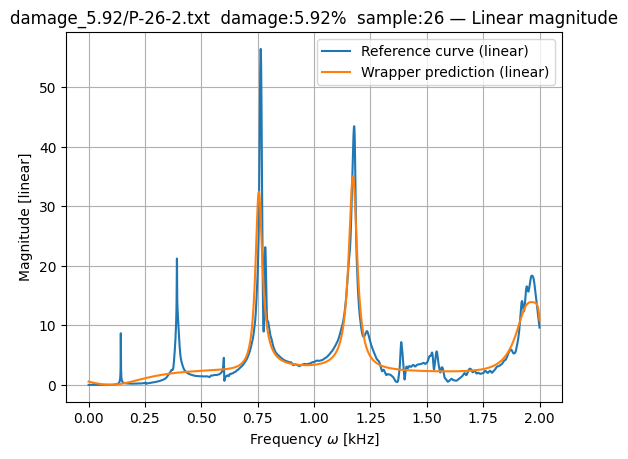

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

EPS_LIN = 1e-12


def db_to_linear_mag(mag_db: np.ndarray) -> np.ndarray:
    mag_db = np.asarray(mag_db, dtype=float)
    return 10.0 ** (mag_db / 20.0)


def linear_to_db_mag(mag_lin: np.ndarray) -> np.ndarray:
    mag_lin = np.asarray(mag_lin, dtype=float)
    mag_lin = np.maximum(mag_lin, EPS_LIN)
    return 20.0 * np.log10(mag_lin)


required = {"f", "damage"}
missing = required - set(FEATURE_TOKENS)
if missing:
    raise ValueError(f"Visualization requires features {required}, missing: {missing}")


rng = np.random.RandomState(SEED)
exp_id, cond, sample, fp = experiments[rng.randint(len(experiments))]

damage_val = DAMAGE_LEVEL[cond]
title_info = f"{exp_id}  damage:{damage_val:.2f}%  sample:{sample}"
print("Plotting:", title_info)


f, mag_db, ph_deg = read_frf_txt(fp)


X_curve, _ = build_feature_matrix(
    f=f,
    mag_db=mag_db,
    ph_deg=ph_deg,
    cond=cond,
    sample=sample,
    feature_tokens=FEATURE_TOKENS,
)


if "f" not in FEATURE_TOKENS:
    raise ValueError("FEATURE_TOKENS must contain 'f' to plot against frequency.")

f_idx = FEATURE_TOKENS.index("f")
omega_plot = X_curve[:, f_idx]


model.eval()
with torch.no_grad():

    Xc = torch.from_numpy(X_curve).float().to(device)

    pred = model(Xc)

    pred_np = pred.detach().cpu().numpy()

    if np.iscomplexobj(pred_np):
        pred_np = pred_np.real

    pred_lin = pred_np.reshape(-1)


y_db = mag_db.reshape(-1)

y_lin = db_to_linear_mag(y_db)

pred_db = linear_to_db_mag(pred_lin)


order = np.argsort(omega_plot)

omega_s = omega_plot[order]
y_db_s = y_db[order]
y_lin_s = y_lin[order]
pred_lin_s = pred_lin[order]
pred_db_s = pred_db[order]


out_dir = Path("figures")
out_dir.mkdir(parents=True, exist_ok=True)


fig_lin = plt.figure()

plt.plot(omega_s, y_lin_s, label="Reference curve (linear)")
plt.plot(omega_s, pred_lin_s, label="Wrapper prediction (linear)")

plt.xlabel(r"Frequency $\omega$ [kHz]")
plt.ylabel("Magnitude [linear]")

plt.legend()
plt.grid(True)

plt.title(f"{title_info} — Linear magnitude")

out_path_lin = out_dir / "frf_prediction_linear.pdf"

fig_lin.savefig(out_path_lin, bbox_inches="tight")

print("Saved to:", out_path_lin.as_posix())